In [1]:
import sys
print(sys.executable)


c:\Users\suprabath reddy\AppData\Local\Programs\Python\Python39\python.exe


In [2]:
!{sys.executable} -m pip install tensorflow==2.15.0 transformers==4.38.2 huggingface_hub==0.22.2 sentencepiece==0.1.99 numpy==1.24.3 pandas==2.0.3 scikit-learn==1.3.2 matplotlib==3.8.0


'c:\Users\suprabath' is not recognized as an internal or external command,
operable program or batch file.


In [3]:
import sys
print(sys.executable)

c:\Users\suprabath reddy\AppData\Local\Programs\Python\Python39\python.exe


In [4]:
%pip install numpy==1.24.3


Note: you may need to restart the kernel to use updated packages.


In [5]:
# Install specific compatible versions for all required packages
%pip install --upgrade --no-cache-dir \
    tensorflow==2.15.0 \
    transformers==4.38.2 \
    huggingface_hub==0.22.2 \
    sentencepiece==0.1.99 \
    numpy==1.24.3 \
    pandas==2.0.3 \
    scikit-learn==1.3.2 \
    matplotlib==3.8.0


Note: you may need to restart the kernel to use updated packages.


In [6]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
import re

# Set seeds for reproducibility
seed_value = 42
os.environ['PYTHONHASHSEED'] = str(seed_value)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)  # For TF 2.15, this is the correct way

# Hugging Face seed
from transformers import set_seed
set_seed(seed_value)

# Version verification
print(f"TensorFlow: {tf.__version__}")      # Should show 2.15.0
print(f"NumPy: {np.__version__}")           # Should show 1.24.3
print(f"Transformers: {__import__('transformers').__version__}")  # Should show 4.38.2
print(f"Pandas: {pd.__version__}")          # Should show 2.0.3


c:\Users\suprabath reddy\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow: 2.15.0
NumPy: 1.26.4
Transformers: 4.38.2
Pandas: 2.0.3


In [7]:
import os
import pandas as pd
import numpy as np
import re

data = pd.read_csv('mbti_1.csv')
print(f"Dataset loaded successfully. Shape: {data.shape}")


Dataset loaded successfully. Shape: (8675, 2)


In [8]:
# Preprocessing function
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply cleaning
data['cleaned_posts'] = data['posts'].astype(str).apply(preprocess_text)

# Show example
print("\nExample of preprocessed text:")
print(data['cleaned_posts'][0][:300], "...")



Example of preprocessed text:
and intj moments sportscenter not top ten plays prankswhat has been the most lifechanging experience in your life on repeat for most of todaymay the perc experience immerse youthe last thing my infj friend posted on his facebook before committing suicide the next day rest in peace enfj sorry to hear ...


In [9]:
# Define binary trait mapping
binary_classes = {
    "I": 0, "E": 1,  # Introversion / Extraversion
    "N": 0, "S": 1,  # Intuition / Sensing
    "T": 0, "F": 1,  # Thinking / Feeling
    "J": 0, "P": 1   # Judging / Perceiving
}

# Convert MBTI types to multi-label binary axes
def mbti_to_binary(mbti_type):
    return [binary_classes[char] for char in mbti_type]

labels = np.array([mbti_to_binary(t) for t in data['type']], dtype='float32')
texts = data['cleaned_posts'].values

# Check shapes
print(f"\nNumber of samples: {len(labels)}")
print(f"First 3 labels: {labels[:3]}")



Number of samples: 8675
First 3 labels: [[0. 0. 1. 0.]
 [1. 0. 0. 1.]
 [0. 0. 0. 1.]]


In [10]:
# Split the dataset
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    texts, labels, test_size=0.3, random_state=seed_value
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=seed_value
)

print(f"Train set: {len(train_texts)} samples")
print(f"Validation set: {len(val_texts)} samples")
print(f"Test set: {len(test_texts)} samples")


Train set: 6072 samples
Validation set: 1301 samples
Test set: 1302 samples


Tokernarization

In [11]:
# Import tokenizer after ensuring everything is properly installed
from transformers import AutoTokenizer, TFAutoModel

# Set up tokenizer
mbert_model_name = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(mbert_model_name)

# Set max sequence length (adjust based on your GPU memory)
MAX_SEQ_LEN = 128

# Tokenization function
def encode_texts(texts, max_length=MAX_SEQ_LEN):
    return tokenizer(
        texts.tolist() if isinstance(texts, np.ndarray) else texts,
        padding='max_length',
        truncation=True,
        max_length=max_length,
        return_attention_mask=True,
        return_token_type_ids=True,
        return_tensors='np'
    )

# Encode the datasets
train_encodings = encode_texts(train_texts)
val_encodings = encode_texts(val_texts)
test_encodings = encode_texts(test_texts)

# Convert to TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((
    {
        'input_ids': train_encodings['input_ids'],
        'attention_mask': train_encodings['attention_mask'],
        'token_type_ids': train_encodings['token_type_ids'],
    },
    train_labels
))

val_dataset = tf.data.Dataset.from_tensor_slices((
    {
        'input_ids': val_encodings['input_ids'],
        'attention_mask': val_encodings['attention_mask'],
        'token_type_ids': val_encodings['token_type_ids'],
    },
    val_labels
))

test_dataset = tf.data.Dataset.from_tensor_slices((
    {
        'input_ids': test_encodings['input_ids'],
        'attention_mask': test_encodings['attention_mask'],
        'token_type_ids': test_encodings['token_type_ids'],
    },
    test_labels
))

# Set batch size and prepare datasets
batch_size = 16
train_dataset = train_dataset.shuffle(1000).batch(batch_size)
val_dataset = val_dataset.batch(batch_size)
test_dataset = test_dataset.batch(batch_size)


In [12]:

# Define MBTI types and axes mapping
mbti_types = ['INFJ', 'ENTP', 'INTP', 'INTJ', 'ENTJ', 'ENFJ', 'INFP', 'ENFP',
              'ISFP', 'ISTP', 'ISFJ', 'ISTJ', 'ESTP', 'ESFP', 'ESTJ', 'ESFJ']
axes = ["I-E", "N-S", "T-F", "J-P"]
binary_classes = {
    "I": 0, "E": 1,  # axis 1
    "N": 0, "S": 1,  # axis 2
    "T": 0, "F": 1,  # axis 3
    "J": 0, "P": 1   # axis 4
}

# Preprocessing function
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove special characters
    text = re.sub(r'[^\w\s]', '', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Replace multiple spaces with single space
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply preprocessing
data['cleaned_posts'] = data['posts'].apply(preprocess_text)

# Print one example
print("\nExample of preprocessed text:")
print(data['cleaned_posts'][0][:200], "...\n")

# Convert MBTI types to multi-label format (one-hot encoded axes)
def mbti_to_binary(personality):
    return [binary_classes[p] for p in personality]

labels = []
for personality in data['type']:
    labels.append(mbti_to_binary(personality))

# Convert to numpy array for tensorflow
labels = np.array(labels, dtype='float32')
texts = data['cleaned_posts'].values

print(f"Number of samples: {len(labels)}")
print(f"First 3 labels: {labels[:3]}")



Example of preprocessed text:
and intj moments sportscenter not top ten plays prankswhat has been the most lifechanging experience in your life on repeat for most of todaymay the perc experience immerse youthe last thing my infj f ...

Number of samples: 8675
First 3 labels: [[0. 0. 1. 0.]
 [1. 0. 0. 1.]
 [0. 0. 0. 1.]]


In [13]:
# Split the dataset
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    texts, labels, test_size=0.3, random_state=seed_value
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=seed_value
)

print(f"Train set: {len(train_texts)} samples")
print(f"Validation set: {len(val_texts)} samples")
print(f"Test set: {len(test_texts)} samples")


Train set: 6072 samples
Validation set: 1301 samples
Test set: 1302 samples


In [14]:
# Import tokenizer after ensuring everything is properly installed
from transformers import AutoTokenizer, TFAutoModel

# Set up tokenizer
mbert_model_name = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(mbert_model_name)

# Set max sequence length (adjust based on your GPU memory)
MAX_SEQ_LEN = 128

# Tokenization function
def encode_texts(texts, max_length=MAX_SEQ_LEN):
    return tokenizer(
        texts.tolist() if isinstance(texts, np.ndarray) else texts,
        padding='max_length',
        truncation=True,
        max_length=max_length,
        return_attention_mask=True,
        return_token_type_ids=True,
        return_tensors='np'
    )

# Encode the datasets
train_encodings = encode_texts(train_texts)
val_encodings = encode_texts(val_texts)
test_encodings = encode_texts(test_texts)

# Convert to TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((
    {
        'input_ids': train_encodings['input_ids'],
        'attention_mask': train_encodings['attention_mask'],
        'token_type_ids': train_encodings['token_type_ids'],
    },
    train_labels
))

val_dataset = tf.data.Dataset.from_tensor_slices((
    {
        'input_ids': val_encodings['input_ids'],
        'attention_mask': val_encodings['attention_mask'],
        'token_type_ids': val_encodings['token_type_ids'],
    },
    val_labels
))

test_dataset = tf.data.Dataset.from_tensor_slices((
    {
        'input_ids': test_encodings['input_ids'],
        'attention_mask': test_encodings['attention_mask'],
        'token_type_ids': test_encodings['token_type_ids'],
    },
    test_labels
))

# Set batch size and prepare datasets
batch_size = 16
train_dataset = train_dataset.shuffle(1000).batch(batch_size)
val_dataset = val_dataset.batch(batch_size)
test_dataset = test_dataset.batch(batch_size)


In [15]:
from transformers import TFAutoModel, AutoTokenizer
import tensorflow as tf

MAX_SEQ_LEN = 128
mbert_model_name = "bert-base-multilingual-cased"

def create_mbert_model():
    # Load model with from_pt=False
    mbert = TFAutoModel.from_pretrained(mbert_model_name, from_pt=False)

    # Define inputs as concrete tensors
    input_ids = tf.keras.Input(shape=(MAX_SEQ_LEN,), dtype=tf.int32, name='input_ids')
    attention_mask = tf.keras.Input(shape=(MAX_SEQ_LEN,), dtype=tf.int32, name='attention_mask')
    token_type_ids = tf.keras.Input(shape=(MAX_SEQ_LEN,), dtype=tf.int32, name='token_type_ids')

    # Get outputs using dictionary input
    outputs = mbert({
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'token_type_ids': token_type_ids
    })

    # Build classification head
    pooled = tf.keras.layers.GlobalAveragePooling1D()(outputs.last_hidden_state)
    x = tf.keras.layers.Dropout(0.1)(pooled)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.1)(x)
    outputs = tf.keras.layers.Dense(4, activation='sigmoid')(x)

    return tf.keras.Model(
        inputs=[input_ids, attention_mask, token_type_ids],
        outputs=outputs
    )

# Create and compile model
model = create_mbert_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(2e-5),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[tf.keras.metrics.BinaryAccuracy(), tf.keras.metrics.AUC()]
)
model.summary()


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.weight', 'cls.predictions.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.bias']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 attention_mask (InputLayer  [(None, 128)]                0         []                            
 )                                                                                                
                                                                                                  
 input_ids (InputLayer)      [(None, 128)]                0         []                            
                                                                                                  
 token_type_ids (InputLayer  [(None, 128)]                0         []                            
 )                                                                                                
                                                                                              

Starting training...
Epoch 1/5

380/380 [==============================] - ETA: 0s - loss: 0.5643 - binary_accuracy: 0.7127 - auc: 0.7537
Epoch 1: val_auc improved from -inf to 0.80379, saving model to mbert_mbti_model\checkpoint
380/380 [==============================] - 3876s 10s/step - loss: 0.5643 - binary_accuracy: 0.7127 - auc: 0.7537 - val_loss: 0.5183 - val_binary_accuracy: 0.7467 - val_auc: 0.8038 - lr: 2.0000e-05
Epoch 2/5
380/380 [==============================] - ETA: 0s - loss: 0.5144 - binary_accuracy: 0.7481 - auc: 0.8076
Epoch 2: val_auc improved from 0.80379 to 0.81040, saving model to mbert_mbti_model\checkpoint
380/380 [==============================] - 3843s 10s/step - loss: 0.5144 - binary_accuracy: 0.7481 - auc: 0.8076 - val_loss: 0.5109 - val_binary_accuracy: 0.7508 - val_auc: 0.8104 - lr: 2.0000e-05
Epoch 3/5
380/380 [==============================] - ETA: 0s - loss: 0.4799 - binary_accuracy: 0.7698 - auc: 0.8367
Epoch 3: val_auc improved from 0.81040 to 0.81062

KeyError: 'accuracy'

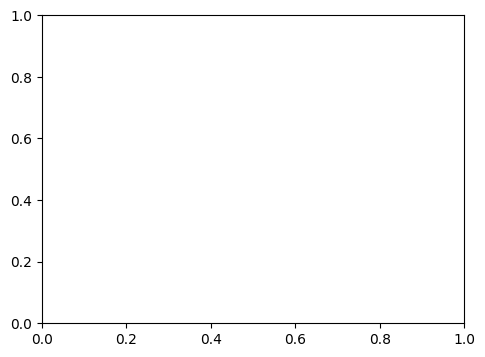

In [16]:
# Create directories for saving model and checkpoints
os.makedirs('mbert_mbti_model', exist_ok=True)

# Define callbacks
callbacks = [
    # Save best model
    tf.keras.callbacks.ModelCheckpoint(
        filepath='mbert_mbti_model/checkpoint',
        save_best_only=True,
        monitor='val_auc',
        mode='max',
        save_weights_only=True,
        verbose=1
    ),
    # Early stopping
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    # Learning rate schedule
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    # TensorBoard logs
    tf.keras.callbacks.TensorBoard(
        log_dir='./logs',
        histogram_freq=1
    )
]

# Train the model
epochs = 5  # Adjust based on performance
print("Starting training...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs,
    callbacks=callbacks,
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.savefig('mbert_mbti_training_history.png')
plt.show()


82/82 [==============================] - 248s 3s/step - loss: 0.5269 - binary_accuracy: 0.7391 - auc: 0.8020

Test loss: 0.5269
Test accuracy: 0.7391
Test AUC: 0.8020
82/82 [==============================] - 264s 3s/step
Introvert-Extrovert Axis Accuracy: 0.7919
iNtuition-Sensing Axis Accuracy: 0.8502
Thinking-Feeling Axis Accuracy: 0.6528
Judging-Perceiving Axis Accuracy: 0.6605


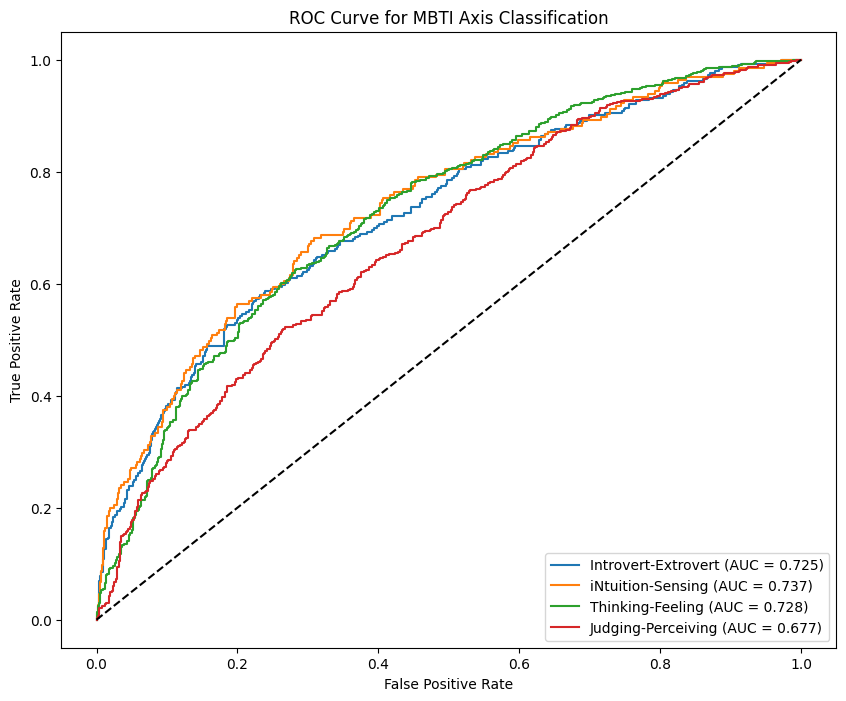

In [17]:
# Evaluate on test set
test_results = model.evaluate(test_dataset, verbose=1)
print(f"\nTest loss: {test_results[0]:.4f}")
print(f"Test accuracy: {test_results[1]:.4f}")
print(f"Test AUC: {test_results[2]:.4f}")

# Get predictions
y_pred_probs = model.predict(test_dataset)
y_pred = (y_pred_probs > 0.5).astype(int)

# Extract labels from test dataset
y_true = np.vstack([y for _, y in test_dataset])

# Calculate accuracy per axis
axis_names = ['Introvert-Extrovert', 'iNtuition-Sensing', 'Thinking-Feeling', 'Judging-Perceiving']
for i, axis in enumerate(axis_names):
    axis_acc = accuracy_score(y_true[:, i], y_pred[:, i])
    print(f"{axis} Axis Accuracy: {axis_acc:.4f}")

# Plot ROC curves
plt.figure(figsize=(10, 8))
for i, axis in enumerate(axis_names):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{axis} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for MBTI Axis Classification')
plt.legend(loc='lower right')
plt.savefig('mbert_mbti_roc_curves.png')
plt.show()


In [18]:
# Save the complete model
model.save('mbert_mbti_model/complete_model')

# Save tokenizer for later use
tokenizer.save_pretrained('mbert_mbti_model/tokenizer')

print("Model and tokenizer saved successfully to 'mbert_mbti_model' directory")


INFO:tensorflow:Assets written to: mbert_mbti_model/complete_model\assets


INFO:tensorflow:Assets written to: mbert_mbti_model/complete_model\assets


Model and tokenizer saved successfully to 'mbert_mbti_model' directory


In [ ]:
def predict_mbti_personality(text, model, tokenizer):
    # Preprocess text
    processed_text = preprocess_text(text)

    # Tokenize
    inputs = tokenizer(
        processed_text,
        padding='max_length',
        truncation=True,
        max_length=MAX_SEQ_LEN,
        return_tensors='tf'
    )

    # Make prediction
    prediction = model.predict({
        'input_ids': inputs['input_ids'],
        'attention_mask': inputs['attention_mask'],
        'token_type_ids': inputs['token_type_ids']
    })

    # Process prediction probabilities
    probs = prediction[0]
    mbti_result = ""

    # Convert probabilities to MBTI type
    mbti_result += "E" if probs[0] > 0.5 else "I"
    mbti_result += "S" if probs[1] > 0.5 else "N"
    mbti_result += "F" if probs[2] > 0.5 else "T"
    mbti_result += "P" if probs[3] > 0.5 else "J"

    # Return results
    return {
        'mbti_type': mbti_result,
        'probabilities': {
            'I-E': {'I': 1-probs[0], 'E': probs[0]},
            'N-S': {'N': 1-probs[1], 'S': probs[1]},
            'T-F': {'T': 1-probs[2], 'F': probs[2]},
            'J-P': {'J': 1-probs[3], 'P': probs[3]}
        }
    }

# Example usage
example_text = "ನಿಮ್ಮ ಧೈರ್ಯ ಮತ್ತು ದಿಟ್ಟ ನಿರ್ಣಯ ಶಕ್ತಿಯು ಈ ಜಗತ್ತಿನಲ್ಲಿ ಬದಲಾವಣೆ ತರಬಲ್ಲ ಶಕ್ತಿ ಹೊಂದಿದೆ. ಮುಂದುವರಿಯಿರಿ – ನಿಮ್ಮ ಪರಿಣಾಮ ಎತ್ತನೇ ಮಟ್ಟದದ್ದಾಗಿದೆ!"

result = predict_mbti_personality(example_text, model, tokenizer)
print(f"Predicted MBTI type: {result['mbti_type']}")
print("\nProbabilities by axis:")
for axis, probs in result['probabilities'].items():
    print(f"{axis}: {probs}")


NameError: name 'model' is not defined

: 